# Decision Tree Regression

In this lesson we train a **DecisionTreeRegressor** on the **Diabetes** dataset.  
We will cover splitting criteria, key hyperparameters, pruning via validation, and interpretation (feature importance and partial dependence).

**Learning objectives**
- Explain how regression trees split to reduce squared error.
- Tune depth/leaf hyperparameters with cross‑validation (HPC‑friendly).
- Diagnose overfitting vs underfitting with plots.
- Interpret models using **feature importance** and **partial dependence**.



## How Regression Trees Work (Theory)

At each node a regression tree chooses a feature $j$ and threshold $t$ to split the data into left/right partitions and **minimize** the **impurity** (here, total squared error):
$$
\text{SSE}(\mathcal{S}) = \sum_{(x_i,y_i)\in \mathcal{S}} (y_i - \bar{y}_{\mathcal{S}})^2.
$$
The best split $(j,t)$ maximizes the **reduction** in SSE:
$$
\Delta = \text{SSE}(\mathcal{S}) - \big[\text{SSE}(\mathcal{S}_L) + \text{SSE}(\mathcal{S}_R)\big].
$$

**Predictions** in a leaf are the mean of training targets in that leaf.  
Key hyperparameters control complexity:
- `max_depth`: maximum tree depth (smaller $\\Rightarrow$ simpler model).
- `min_samples_leaf`: minimum samples per leaf (larger $\\Rightarrow$ smoother predictions).
- `min_samples_split`: minimum samples to split an internal node.
- `ccp_alpha`: **cost‑complexity pruning** strength.


In [1]:
# Load Diabetes dataset
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
import pandas as pd

data = load_diabetes(as_frame=True)
df = data.frame.copy()
df.rename(columns={'target': 'disease_progression'}, inplace=True)

X = df.drop(columns=['disease_progression'])
y = df['disease_progression']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [2]:
# Baseline DecisionTreeRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

tree = DecisionTreeRegressor(random_state=42)
tree.fit(X_train, y_train)

y_pred_train = tree.predict(X_train)
y_pred_test  = tree.predict(X_test)

rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test  = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_train  = mean_absolute_error(y_train, y_pred_train)
mae_test   = mean_absolute_error(y_test, y_pred_test)
r2_train   = r2_score(y_train, y_pred_train)
r2_test    = r2_score(y_test, y_pred_test)

print(f"Train: RMSE={rmse_train:.2f}  MAE={mae_train:.2f}  R^2={r2_train:.3f}")
print(f"Test : RMSE={rmse_test:.2f}   MAE={mae_test:.2f}   R^2={r2_test:.3f}")

Train: RMSE=0.00  MAE=0.00  R^2=1.000
Test : RMSE=70.55   MAE=54.53   R^2=0.061


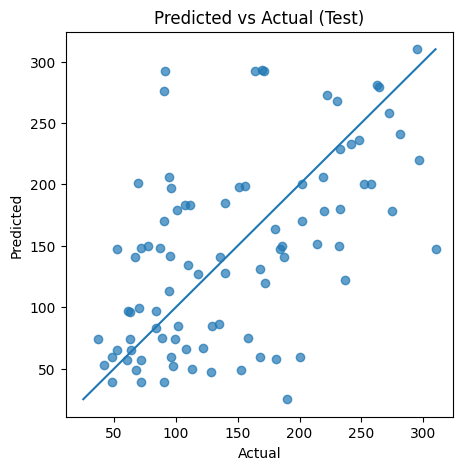

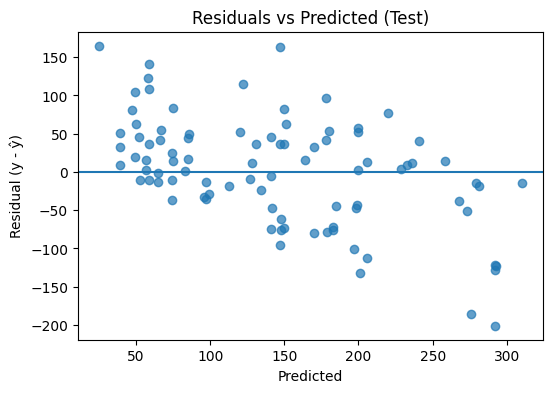

In [3]:
# Diagnostics: predicted vs actual and residuals
import matplotlib.pyplot as plt
import numpy as np

# Predicted vs Actual
plt.figure(figsize=(5,5))
plt.scatter(y_test, y_pred_test, alpha=0.7)
lo = min(y_test.min(), y_pred_test.min())
hi = max(y_test.max(), y_pred_test.max())
plt.plot([lo, hi], [lo, hi])
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual (Test)")
plt.show()

# Residuals vs Predicted
residuals = y_test - y_pred_test
plt.figure(figsize=(6,4))
plt.scatter(y_pred_test, residuals, alpha=0.7)
plt.axhline(0)
plt.xlabel("Predicted")
plt.ylabel("Residual (y - ŷ)")
plt.title("Residuals vs Predicted (Test)")
plt.show()


## Cross‑Validation & Pruning

We tune `max_depth`, `min_samples_leaf`, and `ccp_alpha` using $k$‑fold CV.  
On some HPC setups, default parallelism can fail; we wrap with the **threading backend** (or use `n_jobs=1`).

In [8]:
# Grid search for tree hyperparameters (HPC-friendly)
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.tree import DecisionTreeRegressor
import numpy as np

param_grid = {
    'max_depth': [None, 3, 4, 5, 6, 8],
    'min_samples_leaf': [1, 3, 5, 10],
    'ccp_alpha': [0.0, 0.001, 0.005, 0.01]
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)
tree = DecisionTreeRegressor(random_state=42)


gsv = GridSearchCV(tree, param_grid, scoring='r2', cv=cv, n_jobs=1, refit=True)
gsv.fit(X_train, y_train)

print("Best params:", gsv.best_params_)
print("Best CV R^2:", round(gsv.best_score_, 3))

best_tree = gsv.best_estimator_
y_pred_test_best = best_tree.predict(X_test)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test_best))
mae  = mean_absolute_error(y_test, y_pred_test_best)
r2   = r2_score(y_test, y_pred_test_best)

print(f"Test metrics (tuned): RMSE={rmse:.2f}  MAE={mae:.2f}  R^2={r2:.3f}")

Best params: {'ccp_alpha': 0.0, 'max_depth': 4, 'min_samples_leaf': 3}
Best CV R^2: 0.284
Test metrics (tuned): RMSE=58.50  MAE=46.47  R^2=0.354



## Visualizing the Tree

We can visualize the learned splits. For readability, limit depth (or use the tuned tree if it's shallow).

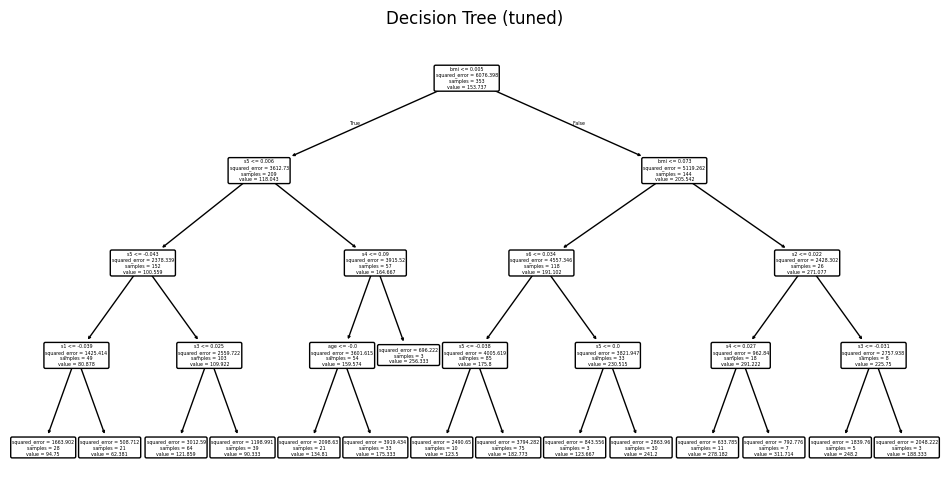

In [5]:
# Plot the tree (may be large if depth is high)
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plot_tree(best_tree, feature_names=X.columns, filled=False, impurity=True, rounded=True)
plt.title("Decision Tree (tuned)")
plt.show()


## Interpretation: Feature Importance & Partial Dependence

- **Feature importance** (impurity decrease) provides a **global** ranking of influential features.
- **Partial dependence** plots show the **marginal effect** of one or two features on the prediction while averaging over others.


bmi    0.632805
s5     0.214185
s6     0.057076
s4     0.025199
s3     0.024707
dtype: float64


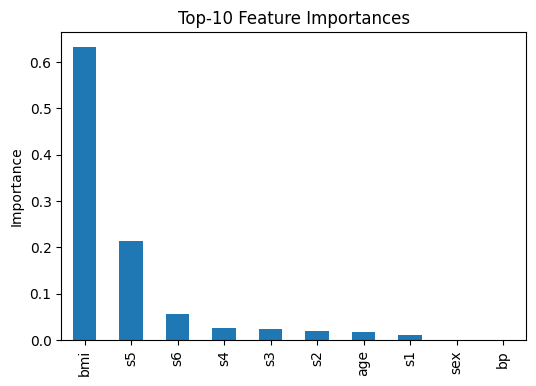

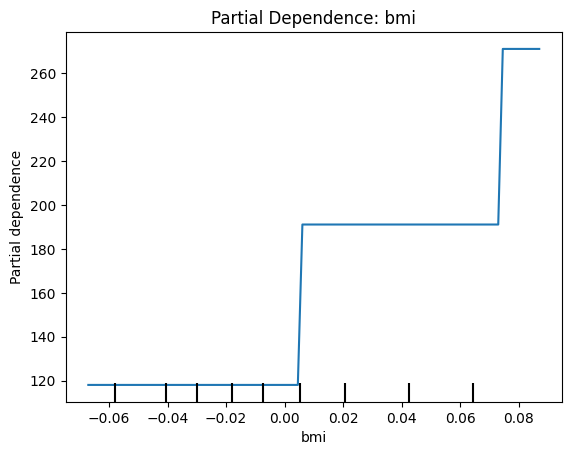

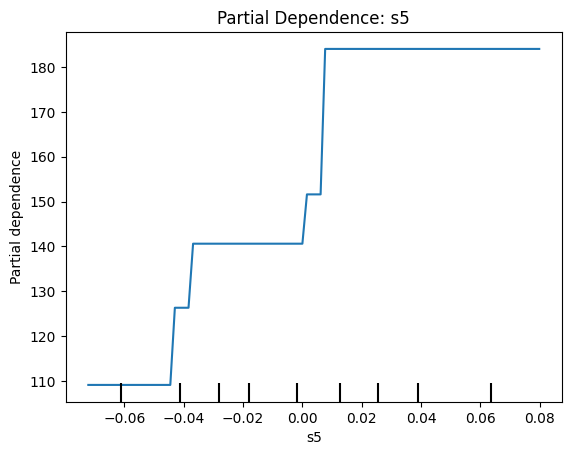

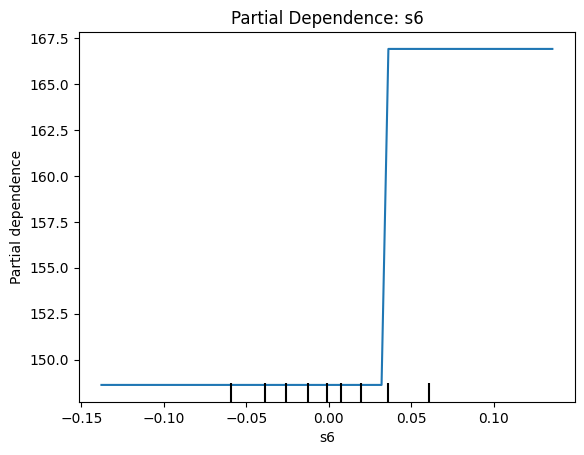

In [6]:
# Feature importance
import pandas as pd
import matplotlib.pyplot as plt

fi = pd.Series(best_tree.feature_importances_, index=X.columns).sort_values(ascending=False)
print(fi.head())

plt.figure(figsize=(6,4))
fi.head(10).plot(kind='bar')
plt.ylabel("Importance")
plt.title("Top-10 Feature Importances")
plt.show()

# Partial dependence (1D) for a few top features
try:
    from sklearn.inspection import PartialDependenceDisplay
    top_feats = fi.head(3).index.tolist()
    for feat in top_feats:
        PartialDependenceDisplay.from_estimator(best_tree, X, [feat])
        plt.title(f"Partial Dependence: {feat}")
        plt.show()
except Exception as e:
    print("PartialDependenceDisplay not available:", e)


## Learning Curve

Learning curves indicate if more data would help or if the model is variance‑limited vs bias‑limited.


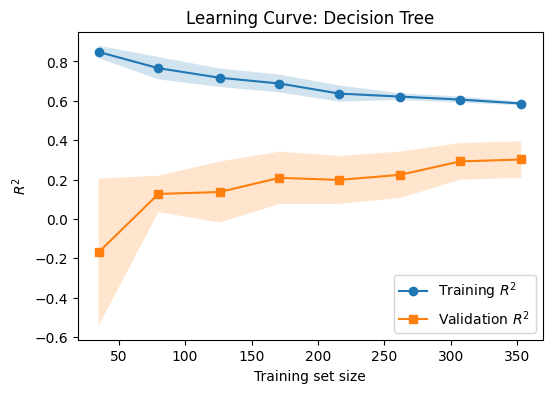

In [7]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

train_sizes, train_scores, val_scores = learning_curve(
    estimator=best_tree,
    X=X, y=y,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=5,
    scoring='r2',
    n_jobs=1,   # keep simple for portability
    shuffle=True,
    random_state=42
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

plt.figure(figsize=(6,4))
plt.plot(train_sizes, train_mean, marker='o', label='Training $R^2$')
plt.plot(train_sizes, val_mean, marker='s', label='Validation $R^2$')
plt.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.2)
plt.fill_between(train_sizes, val_mean-val_std,   val_mean+val_std,   alpha=0.2)
plt.xlabel("Training set size")
plt.ylabel("$R^2$")
plt.title("Learning Curve: Decision Tree")
plt.legend()
plt.show()


## Summary

- Trees split to reduce squared error and can model **non‑linear** relationships.
- They are prone to **overfitting**; tune `max_depth`, `min_samples_leaf`, and `ccp_alpha`.
- Use diagnostics, learning curves, feature importance, and partial dependence for interpretation.



## Exercises

1. **Validation curve:** Plot validation $R^2$ as a function of `max_depth` and `min_samples_leaf` separately.
3. **Target transform:** Fit a tree to predict $\\log(1+y)$ and compare test $R^2$.
4. **Robustness:** Change the random seed and redo GridSearchCV. How stable are the chosen hyperparameters?
